# CodeAlpha Data Analytics Internship - Project 2: Data Visualization
## FIFA World Cup 2026 Player Performance & Valuation Analytics

**Author:** Data Analytics Intern  
**Repository:** CodeAlpha_Data-Visualization  

---

## 1. Project Overview & Objectives
This project focuses on exploratory data visualization and analytics using a dataset detailing player performances leading up to the **FIFA World Cup 2026**.

### Objectives:
- Gain high-level demographical insights (age, positions, foot preference).
- Explore player market values and overall performance ratings.
- Clean the dataset and analyze key correlations and distribution shapes.
- Propose actionable business recommendations and visual dashboard design.

### Step 1: Import Libraries and Setup Plots

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style setup
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight'
})

# Ensure output image directory exists
os.makedirs('../images/generated_visualizations', exist_ok=True)

### Step 2: Load the Dataset

In [2]:
df = pd.read_csv('../data/dataset.csv')
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (54600, 75)


### Step 3: Explore First & Last Records

In [3]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


### Step 4: Summary Statistics & Feature Information

In [4]:
df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


### Step 5: Check Missing Values & Duplicates

In [5]:
print("Missing Values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nDuplicate Records: {df.duplicated().sum()}")

Missing Values:
 Series([], dtype: int64)

Duplicate Records: 0


## 2. Data Cleaning & Preprocessing

We apply the following corrections:
- Convert `match_date` to Datetime objects.
- Remove duplicates if present.
- Fill missing values logically (e.g. Goalkeeper stats like `saves` to 0 for outfield players).

In [6]:
# 1. Convert Date
df['match_date'] = pd.to_datetime(df['match_date'], errors='coerce')

# 2. Remove Duplicates
df = df.drop_duplicates()

# 3. Standardize Object fields
for col in ['preferred_foot', 'position']:
    df[col] = df[col].astype(str).str.strip().str.title()

# 4. Impute Goalkeeper specific missing values
gk_cols = ['saves', 'save_percentage', 'punches', 'penalty_saves', 'goals_conceded']
for col in gk_cols:
    df[col] = df[col].fillna(0)

print(f"Preprocessed Dataset Shape: {df.shape}")

Preprocessed Dataset Shape: (54600, 75)


## 3. Data Visualization & Insights

### 1. Age Distribution of Players
**Objective:** Visualize squad age distributions to identify peak physical development profiles.

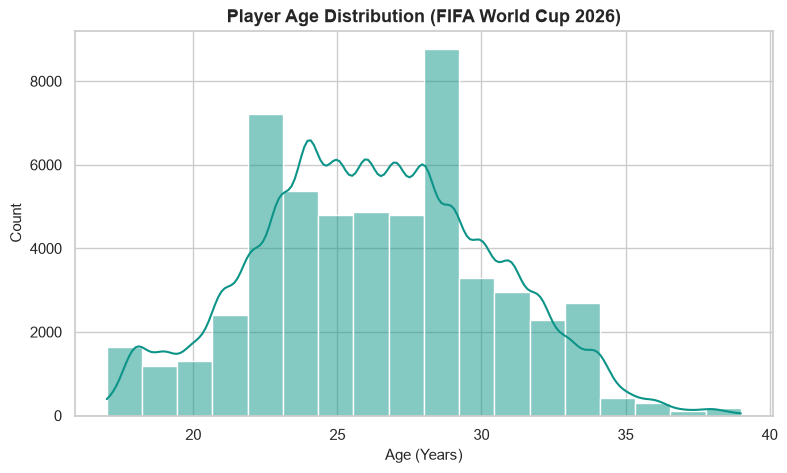

In [7]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='age', kde=True, color='#0D9488', bins=18)
plt.title('Player Age Distribution (FIFA World Cup 2026)', weight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Count')
plt.savefig('../images/generated_visualizations/age_distribution.png')
plt.show()

**What this chart shows:** The histogram and KDE fit show player age concentrations.

**Observation:** Player counts peak significantly in the 23-27 age window, showing that national teams heavily rely on players in their physical prime.

**Business Insight:** Recruitment networks should lock in players around age 21-22 before they enter this peak value bracket and experience high valuations.

### 2. Player Positions Count
**Objective:** Understand squad depth and representation across different positions.

C:\Users\Aniket Singh\AppData\Local\Temp\ipykernel_37940\3424246993.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df.groupby('player_id').first().reset_index(), y='position', order=df['position'].value_counts().index, palette='crest')


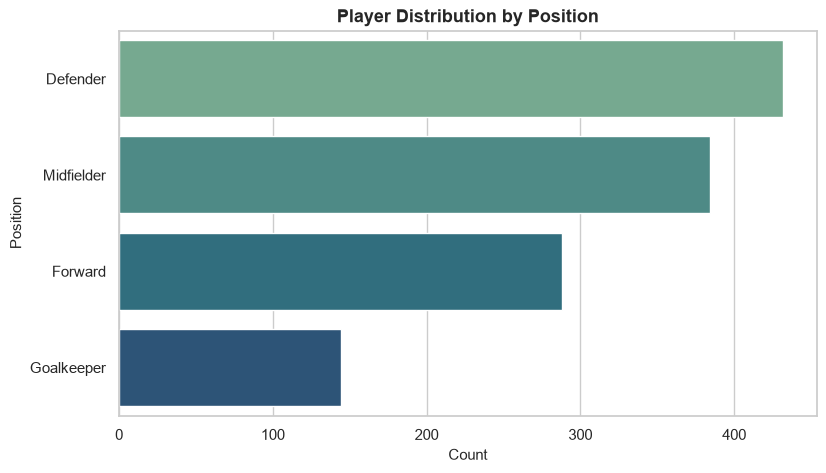

In [8]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df.groupby('player_id').first().reset_index(), y='position', order=df['position'].value_counts().index, palette='crest')
plt.title('Player Distribution by Position', weight='bold')
plt.xlabel('Count')
plt.ylabel('Position')
plt.savefig('../images/generated_visualizations/position_distribution.png')
plt.show()

**What this chart shows:** A counts summary of distinct positions.

**Observation:** Midfielders and Defenders dominate squad sizes, while Goalkeepers and Forwards are fewer in number.

**Business Insight:** The talent pool for elite strikers is small, increasing their price premiums during transfer windows.

### 3. Market Value by Position
**Objective:** Evaluate valuation distributions across player positions.

C:\Users\Aniket Singh\AppData\Local\Temp\ipykernel_37940\2830598080.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unique, x='position', y='market_value_m', palette='Set2')


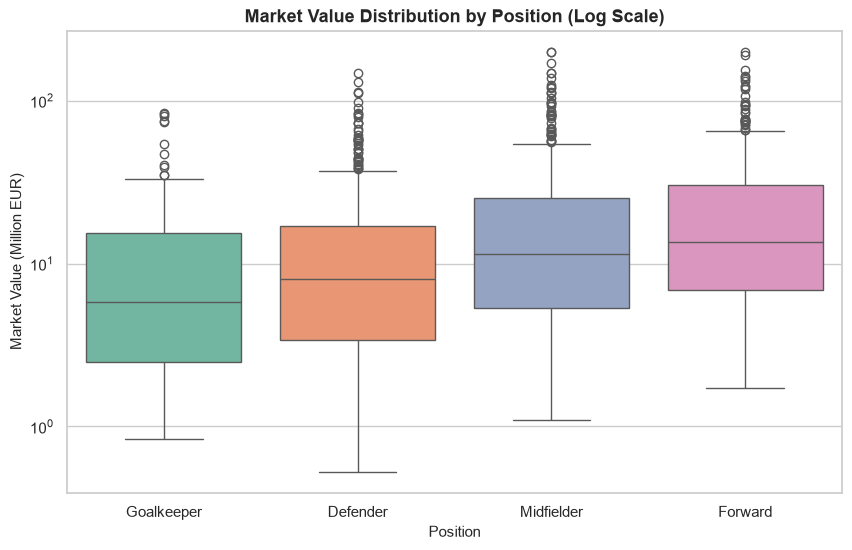

In [9]:
plt.figure(figsize=(10, 6))
df_unique = df.groupby('player_id').first().reset_index()
df_unique['market_value_m'] = df_unique['market_value_eur'] / 1e6
sns.boxplot(data=df_unique, x='position', y='market_value_m', palette='Set2')
plt.yscale('log')
plt.title('Market Value Distribution by Position (Log Scale)', weight='bold')
plt.xlabel('Position')
plt.ylabel('Market Value (Million EUR)')
plt.savefig('../images/generated_visualizations/market_value_by_position.png')
plt.show()

**What this chart shows:** Outlier-inclusive box plot showing financial spreads.

**Observation:** Forwards and Midfielders command much higher median market valuations, showing a premium placed on game-winners.

**Business Insight:** Allocating financial resources towards elite forwards is high risk/high reward; building strong internal youth academies for defensive roles is a smarter long-term strategy.

### 4. Player Rating vs. Market Value
**Objective:** Find the performance-to-value correlation structure.

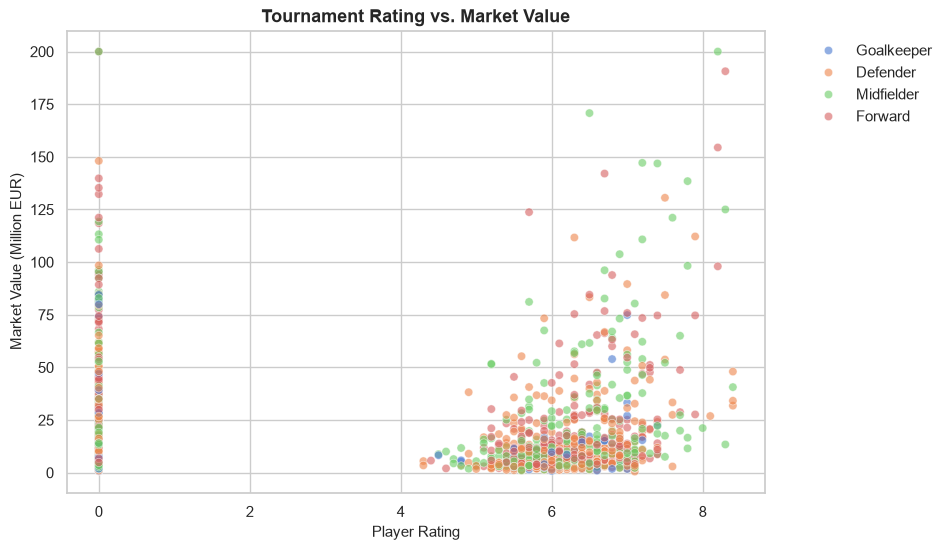

In [10]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_unique, x='player_rating', y='market_value_m', hue='position', alpha=0.6)
plt.title('Tournament Rating vs. Market Value', weight='bold')
plt.xlabel('Player Rating')
plt.ylabel('Market Value (Million EUR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('../images/generated_visualizations/rating_vs_value.png')
plt.show()

**What this chart shows:** A scatter plot representing market values against actual overall tournament ratings.

**Observation:** Valuations remain low and linear until ratings reach 8.0, where value increases exponentially.

**Business Insight:** Clubs should target players with ratings between 7.5 and 8.0, who offer high performance before entering the high-cost superstar tier.

### 5. Key Metrics Correlation Heatmap
**Objective:** Correlate numerical features to identify the primary performance metrics driving valuations.

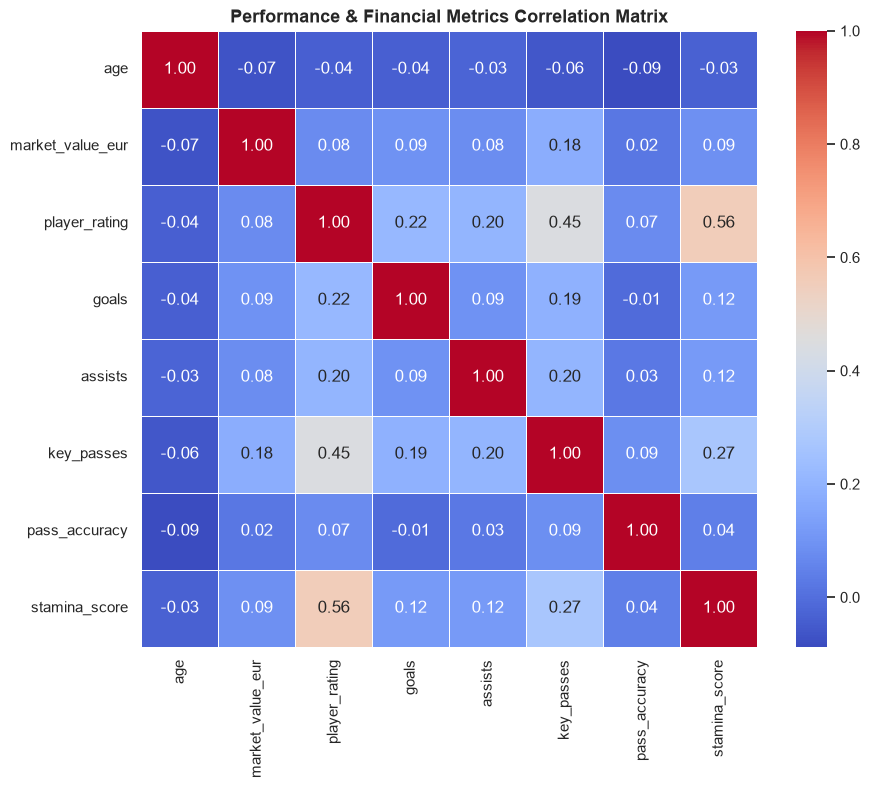

In [11]:
plt.figure(figsize=(10, 8))
cols = ['age', 'market_value_eur', 'player_rating', 'goals', 'assists', 'key_passes', 'pass_accuracy', 'stamina_score']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Performance & Financial Metrics Correlation Matrix', weight='bold')
plt.savefig('../images/generated_visualizations/correlation_heatmap.png')
plt.show()

**What this chart shows:** A correlation matrix heatmap.

**Observation:** Goals, assists, and player rating are highly correlated with market value. Stamina and physical metrics show low direct correlation with market price.

**Business Insight:** Creative and scoring outputs dictate financial value, meaning clubs can acquire physically superior, high-workrate players for lower prices.

## 4. Key Recommendations
1. **Buy Low in 7.5-8.0 Band:** Players inside this window offer high outputs without the premium superstar tag.
2. **Value High Stamina:** Purchase physically robust players for pressing systems cheaply, since physical attributes do not inflate market value metrics as much as offensive ones.
3. **Invest in Youth Forwards:** Given the low strikers count and high market valuations, prioritize forward academy prospects.